# Task 1 — Forecasting Across Heterogeneous Sensors

AI651 / CS434 / EE5108 · implementation notebook

Use the Task 1 handout in `main.pdf` for concepts and response instructions. This notebook
contains the implementations, checks, and outputs for each part.

The simulated setting is a 20 Hz four-station production line. Products A, B, and C set global
nominal pace ranges of 14--18, 21--27, and 28--36 samples; each operating run has one actual pace from
its product range. Stations 1--3 are established and station 4 is held out.

Write every assessed response in your report. Each part has its own simple rhythm:
inspect its **Outputs**, then write its named **Response**.

| Part | You implement | Outputs | Response |
| --- | --- | --- | --- |
| 0. The World and Forecasting Setup | — | — | — |
| 1. Context-Dependent Forecasting | Raw Attention forecaster | 1.1–1.3 | 1A, 1B |
| 2. Separate Slow Structure from Repetition | `SeriesDecomposition.forward` | 2.1–2.3 | 2 |
| 3. Mix by Temporal Delay | `aggregate_delays` (`delay_scores` is supplied) | 3.1–3.2 | 3 |
| 4. Compare Designs and Deploy | — | 4.1–4.3 | 4 |

Short-horizon vibration forecasts provide the expected near-term baseline for condition monitoring.
Deviations from that expected behavior can indicate abnormal operation.

**Every implementation is checked where you write it.** Each implementation has a clear contract
and an immediate check; the numerical components also include small worked examples. Checks test
values, shapes, and gradients and name the likely cause when they fail. Nothing is left for a
training run to discover.


## 0. The World and Forecasting Setup

**Physical line:** Station 1 → Station 2 → Station 3 → Station 4. Each station has one vibration
accelerometer sampled at 20 Hz. Stations 1–3 are established; Station 4 is held out from fitting
but still supplies its own 96-sample context at inference time.

| Product | Actual pace in each operating run |
| --- | --- |
| A | 14–18 samples per cycle |
| B | 21–27 samples per cycle |
| C | 28–36 samples per cycle |

Each reading combines a slow drift, a repeating vibration, and small noise. A forecast receives
`L=96` readings from one station and predicts `H=48` future readings. Windows never cross a product
changeover. Train is samples 0–9600, validation is 9600–12480, and final test is 12480–15360.
Anchoring and scaling are supplied and use established-station training data only.

### Environment setup

Use Python 3.11 or later. From the unzipped assignment directory:

```bash
python -m venv .venv
# Linux/macOS:
source .venv/bin/activate
# Windows PowerShell:
# .venv\Scripts\Activate.ps1
python -m pip install -r requirements.txt
jupyter lab
```

For CPU-only PyTorch, install it from its CPU wheel index before installing the remaining
requirements:

```bash
python -m pip install torch --index-url https://download.pytorch.org/whl/cpu
python -m pip install -r requirements.txt
```

Keep `harness/` and `requirements.txt` beside this notebook.

#### Important: The notebook starts with PA1_PRESET=smoke only to make implementation and debugging fast. All results used in your report must come from a fresh PA1_PRESET=full run. 

In [1]:
import os
import math
import sys
from pathlib import Path

for candidate in (Path("harness"), Path("PA 01/harness"), Path("../harness")):
    if candidate.is_dir():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise FileNotFoundError("Keep harness/ beside this notebook and start Jupyter there.")

import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.nn import functional as F
from IPython.display import display
import design_controls as design
import design_data as data
import design_diagnostics as figures
import design_reporting as report

preset = os.environ.get("PA1_PRESET", "full")
seed = int(os.environ.get("PA1_SEED", "0"))
model_seed = int(os.environ.get("PA1_MODEL_SEED", str(seed)))
study = design.Study(preset, seed, model_seed=model_seed)
assert design.check_world(study.world)
print(f"preset={preset}; data seed={seed}; model seed={model_seed}; device={design.device}")
print(f"sampling rate={data.SAMPLING_RATE_HZ:g} Hz; products={', '.join(study.world.product_names)}")
print(f"product pace ranges={study.world.product_period_bands.tolist()} samples; "
      f"established stations={study.established.sum()}; held-out station=4")
print(f"eligible train/validation/test origins: "
      f"{len(study.region('train')['origins'])}/"
      f"{len(study.region('validation')['origins'])}/"
      f"{len(study.region('test')['origins'])}")



Four-station product-line world checks passed.
preset=full; data seed=0; model seed=0; device=cuda
sampling rate=20 Hz; products=Product A, Product B, Product C
product pace ranges=[[14.0, 18.0], [21.0, 27.0], [28.0, 36.0]] samples; established stations=3; held-out station=4
eligible train/validation/test origins: 650/105/105


## 1. Context-Dependent Forecasting

The handout ends Part 1 by wrapping Attention in an encoder and naming the result
**Raw Attention**: the forecaster every later section improves. Building it is your first
implementation, and it has to exist before any of Part 1's evidence can be produced.

Before the comparison, write the ordering you expect for **Response 1A**.

Produces **Outputs 1.1–1.3** → used in **Responses 1A and 1B**.


### Assemble the forecaster

At this point there is only one model: **Raw Attention**. It embeds the raw context, uses
Attention to mix positions, then predicts the next 48 readings.

Routine layers are complete. **You write the `RawAttentionForecaster.forward` assembly.**
Input `context` is `[B, L, 1]`; `self.embed` wants `[B, channels, L]` and returns `[B, d, L]`;
the encoder blocks use `[B, L, d]`; flatten that final representation before the forecast head
to return `[B, H]`.

The next cell immediately checks the output shape and gradient flow.


In [2]:
class DenseAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads = heads
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.last_attention = None

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).transpose(1, 2)
                   for layer in (self.query, self.key, self.value))  # [B,h,L,d_h]
        weights = (q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])).softmax(-1)
        self.last_attention = weights.detach()  # [B,h,L,L]
        mixed = (weights @ v).transpose(1, 2).reshape(batch, length, width)
        return self.out(mixed)                  # [B,L,d]

class RawAttentionBlock(nn.Module):
    def __init__(self, d, heads, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
    def forward(self, x):                       # [B,L,d]
        x = x + self.drop(self.mix(self.norm1(x)))
        return x + self.drop(self.feed_forward(self.norm2(x)))

class RawAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 dropout=0.1):
        super().__init__()
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([RawAttentionBlock(d, heads, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # context [B,L,1] -> return [B,H]
        # self.embed wants [B,1,L], then produces [B,d,L]. After transposing back, add
        # self.position, pass through every block and self.norm, flatten [B,L,d], and use
        # self.forecast_head to return [B,H].

        x = context.transpose(1, 2)  # [B,1,L] -> [B,L,1]
        x = self.embed(x)  # [B,L,1] -> [B,d,L]
        x = x.transpose(1, 2)  # [B,d,L] -> [B,L,d]
        x = x + self.position  # [B,L,d] + [1,L,d] -> [B,L,d]
        for block in self.blocks:
            x = block(x)  # [B,L,d] -> [B,L,d]
        x = self.norm(x)  # [B,L,d] -> [B,L,d]
        x = x.flatten(1)  # [B,L,d] -> [B,L*d]
        x = self.forecast_head(x)  # [B,L*d] -> [B,H]
        return x
    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]

    # self-notes for later: 
    # We start with context: [B, L, 1]
    # Since self.embed is a Conv1d, it expects input of shape [B, C_in, L], where C_in is the number of input channels. 
    # In this case, C_in is 1 (the last dimension of context). So we need to transpose context to [B, 1, L] before passing it to self.embed. 
    # After embedding, we get [B, d, L], which we then transpose back to [B, L, d].
    # Then we add positional encoding, pass through the attention blocks, normalize, flatten, and finally use the forecast head to get the output of shape [B, H].



In [3]:
assert design.check_raw_attention_assembly(RawAttentionForecaster)
design.register_components(raw_forecaster_type=RawAttentionForecaster)


Raw-Attention assembly and gradient checks passed.


## Response 1A

### Predicted Response before Running Output 1.1

Expected ordering (best to worst RSME):
1. Period-routed ridge
2. Raw attention
3. Sensor-specific ridge
4. Shared ridge

Expected ordering for held-out station 4:
should be the same except the Sensor-specific ridge will not be able to produce a forecase at all (because no matrix will be fitted for a station it never saw).

Why? Station identity and amplitude are essentially irrelevant here: a station changes pace many times. A single matrix for all stations should perform the worst while a matrix for each station should perform better than shared ridge since the weights will be more specialized for each station. Period routing is the only forecaster that is told which quantity changes, so it should be clearly ahead. Raw attention builds its mixing per context, so it should beat any fixed map, but it has to discover the phase advance from 1950 training windows in 6000 steps so I expect it to stay behind a model that is handed the pace.

### Final Response after Running Output 1.1

Sensor-specific ridge is 0.001 m/s^2 worse than the shared map on the established stations (0.768 against 0.767), so fitting one matrix per station buys nothing and costs three times the parameters. Raw Attention cuts RMSE by 47% against the shared map (0.767 to 0.407) and MSE by 72% (0.588 to 0.165). Period-routed ridge cuts RMSE by 78% and MSE by 95% (0.588 to 0.028), and beats Raw Attention by a factor of 2.4 in RMSE and 6.0 in MSE. On held-out station 4 the ordering is unchanged and the routed margin widens: 0.173 against 0.571 for Raw Attention and 0.876 for the shared map. 

The spread across products inside one model is at most 30% of that model's own RSME, while the spread acrosss models reaches 4.6x. The fixed maps and Raw Attention are worst on Product B and best on Product C, but the routed ridge is worst on Product A (0.181 against 0.164 and 0.152). The reason is in the targets (not in the models): the slow part has the same standard deviation for every product (3.35 to 3.36 m/s^2) while the fast cycle is largest for Product B (1.49 against 1.41 for C and 1.31 for A) and the 48-step horizon must extrapolate about 3.0 cycles at a Product A pace against 1.5 at a Product C pace, so a given relative phase error costs more when the pace is fast.

- Shared ridge assumes one linear map fits every window. It is not wrong about the slow part: its slow-part RMSE is 0.230 m/s^2 against a slow-part standard deviation of 3.36, because a ramp extrapolates well. It is wrong about the cycle: its fast-part RMSE is 0.777 against a fast-part standard deviation of 1.40, and only 14% to 31% of its forecast variance sits at the run's true pace, against 27% to 41% in the target itself.
- Sensor-specific ridge assumes windows differ mainly by which station produced them. They do not: the pace changes within a station, so the per-station matrix faces the identical compromise and reproduces the shared result to within 0.001 m/s^2. It is also the only model that cannot be used on station 4 at all.
- Period-routed ridge assumes windows differ mainly by operating pace, which is the one assumption the environment actually satisfies. It routes each window to one of 13 pace bands of 1.5 samples, so its forecast is a compromise only within a band of 1.5 samples rather than across the whole 14 to 36 sample range.
- Raw Attention assumes the right mixing can be computed from the window itself. It succeeds on the cycle: median amplitude at the true pace 0.97 to 1.02, phase error within 1% of a cycle, and at most 4% of windows off by more than a tenth of a cycle. Its remaining error is mostly slow structure (slow share of MSE 0.23).

**Revision of my prediction:**

1. I did not expect the routed ridge to beat Raw Attention by 2.4x in RMSE, having said the gap should not exceed a factor of 2. I had assumed extra capacity would narrow the gap to a fixed linear map. The measurement says the opposite: once the pace is known, the 48-step continuation of this signal is very nearly a linear function of the anchored context, so a 96x48 map per pace band already captures it and the extra capacity is spent on slow structure instead.
2. Raw Attention improved on the shared map by 1.9x in RMSE, just outside the 2x to 4x I predicted, so my capacity intuition was slightly optimistic. It is still the second largest effect in the table, a 47% RMSE cut.
3. I did not expect sensor-specific ridge to be *identical* to the shared map rather than merely close. This is the cleanest possible evidence that station identity is the wrong variable.
4. My product-level explanation was wrong even though the product ordering was right for three of the four models. I attributed the ease of Product C to a compromise centred near the slow pace; the actual driver is the amount of fast-cycle energy in the target combined with the number of cycles the horizon must extrapolate, which is a property of the data, not of the model.


## Response 1B

Output 1.2 puts Station 1 under two products, so amplitude, phase and drift are held roughly constant and only the pace changes: 16.13 samples for Product A, 30.09 for Product C.

In the figure the shared and sensor-specific curves keep the level and the slow ramp of the context but their cycle is visibly flatter than the truth's and its peaks sit inside the true peaks rather than under them. Measured at each window's true pace, the shared map's cycle has 0.69 of the target's amplitude on Product A and 0.77 on Product C, against 0.95 and 0.98 for the routed map. Its median phase error is small (-0.7% to +3.2% of a cycle), so the typical failure is attenuation rather than gross mis-phasing, but 10% to 28% of its validation windows are off by more than a tenth of a cycle, against 0% for the routed map.

Why? For a repeating signal the right linear map is a phase advance matched to the pace. The pace changes within a station, so least squares over paces 14 to 36 returns an average of incompatible phase advances, and `W_hat` has no input that could select among them: the operator cannot depend on anything except the multiplication by `x`. Sensor-specific ridge reproduces the same numbers (0.787 and 0.436) because re-fitting per station changes the row population, not the fact that each matrix still faces every pace.

`W_Q`, `W_K`, `W_V` are three 64x64 matrices learned once, not indexed by window, station or time. Everything computed from them is recomputed per context:

1. The current window is projected, so `Q = x W_Q`, `K = x W_K`, `V = x W_V`. A different window gives different `Q` and `K` from the same projections.
2. The `L^2` pair scores are rebuilt from those features on every forward pass (`Q K^T / sqrt(d_h)`), and the softmax turns each row into a fresh distribution over the 96 keys. This is the step the fixed map does not have.
3. The output at each position is that fresh distribution applied to the values, so the value-mixing operation is a function of the window: change the window and the operator changes, with no refit and no router.

Output 1.3 shows this. Both maps for Station 1 are valid attention matrices (every row sums to 1), they differ on all 96 rows, and 391 of the 9,216 pairs move by more than 0.05. The largest change is
0.439: at key position 92 the weight is 0.000 under Product A and 0.439 under Product C. The mean absolute difference is only 0.013 because most entries are near zero in both maps, so the mean
understates what happens where the mixing concentrates.

Ridge applies one `W_hat` to every window, so the map from the last 96 values to the next 48 is the same function for a Product A window and a Product C window. Attention factorises it into a shared part (`W_Q`, `W_K`, `W_V`) and a context-computed part (the weights), which is how it obtains a family of operators indexed by the window itself.

Output 1.3 do not show that Attention recovered the physical period. The largest differences sit at late key positions (92, 91, 88) rather than at a displacement of 16 or 30 samples, and collapsing each map by displacement gives a nearly flat profile (largest mean weight 0.015 against a uniform 0.010). The supported claim is only that the mixing weights depend on the input context. Raw Attention still loses to the routed ridge here (0.386 against 0.232 on Product A), so a context-dependent mixer is necessary but not sufficient, which Parts 2 and 4 address.


## Response 2

Chosen on established-station **training** windows by Output 2.2's criterion, the share of contexts
whose estimated pace is within one sample of the generator's true pace.

| width | residual std (m/s^2) | trend range (m/s^2) | Output 2.2 recovery within 1 sample | median abs. period error (samples) |
|---|---|---|---|---|
| 17 | 0.578 | 8.768 | 0.980 | 0.157 |
| 25 | 1.012 | 8.037 | 0.989 | 0.122 |
| 33 | 1.372 | 8.076 | 0.993 | 0.142 |
| **41 (selected)** | 1.572 | 8.280 | **0.998** | 0.216 |
| raw, no split | | | 0.687 | 0.525 |

**Output 2.1** (Station 2, Product C, the window where the raw estimator is worst, true pace 32.0).
The trend range is nearly width-independent (8.04 to 8.77), so every candidate captures the same
slow range. The residual grows with width (0.578 to 1.572) because a wider filter leaks more drift
into the remainder, and its shape changes qualitatively: at 17 the window is narrower than the
32-sample cycle, so the trend bends with the vibration and the remainder is too small; at 41 the
window is wider than the slowest pace band (36) and the remainder is a clean oscillation. The third
panel shows why that matters: after the split the projection score has one sharp peak at the true
32.0 samples, while on the raw context it is nearly flat over 15 to 36. The selected trend is also
visibly flatter over the first and last 20 positions, the replicate-padded half-width.

**Output 2.2** is the criterion, on training windows only. The split is what makes the pace visible
at all (0.687 to 0.98 or better). Width 41 wins even though 25 has the lowest median error, which
is the criterion working as intended: routing needs the estimate inside the correct 1.5-sample band
and the delay band needs the peak inside 8 to 48, so a within-one-sample guarantee is what both
decisions need, and sub-sample precision changes neither.

**Output 2.3** confirms it downstream, on validation, without the oracle. Established pooled RMSE
0.407 to 0.302, MSE 0.165 to 0.091 (-45%), MAE 0.305 to 0.226; per product 0.384/0.437/0.397 to
0.279/0.339/0.283. Held-out station 4: 0.571 to 0.455, per product 0.558/0.560/0.593 to
0.402/0.493/0.466. The gain is in all six population-by-product cells, so it is not carried by one
regime. The cost is 4,656 extra parameters, the `96 x 48` trend head, 1.3% of the model.

## Why this bias, and why this selector

The world is drift plus repetition with the scales separated by construction (240 samples against
14 to 36), so a centred low-pass split with a cutoff between them is the correct prior, not a
convenience, and it costs no parameters. It makes the encoder's input scale independent of the
local drift slope, it makes the trend smooth enough for one linear head, and it removes Part 3's
problem before it arises: a rising ramp is similar to itself after every shift, so any
shift-and-compare score on the raw context is dominated by the ramp. Output 3.2 shows exactly that:
on the raw signal the correlation is negative across most of the 8 to 48 band and never returns to a
positive peak, while the residual peaks at 0.90 at 16 and 32 samples.

The oracle diagnostic is the right selector because what is being bought is a property of the
*filter*: does this width leave the repetition visible? That can be measured once, on training
windows, against the only ground truth simulation has. It keeps the choice away from validation and
test data and keeps the oracle out of the forecaster, since the true period is never an input or a
routing variable. Output 2.3 then confirms the choice the honest way, on validation error, without
the oracle.

## Where it fails, and one alternative

It encodes "locally constant trend, everything faster is detail", so it fails when the scales are not
separated: a cycle slower than the width would be absorbed into the trend and the linear head would
extrapolate a cycle as a straight line, while a drift faster than the width would push real slow
structure into the remainder. The sharpest case is a step inside the window, for instance a
changeover or an impact, which a centred average smears across the full width. An alternative is a
fixed-order local polynomial (Savitzky-Golay) trend, which encodes "locally smooth with bounded
curvature" instead of "locally constant" and would not flatten a kink; it gives up parameters
(replicated at every layer, since the split is applied after each residual sublayer) and the
guarantee that the trend is a plain local mean. With drift this smooth I would not expect it to pay
for itself.


### Evidence

| Cell below | Output | Read it for |
| --- | --- | --- |
| fit Raw Attention, then compare four forecasters | 1.1 | Response 1A — then revise the ordering you wrote |
| the same station under two products | 1.2 | Response 1B |
| Attention behaviour across two contexts | 1.3 | Response 1B |

The three ridge forecasters are supplied; you implement nothing for them.


In [4]:
study.train("Raw Attention")
report.publish("1.1", report.comparison(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Raw Attention: 6000 steps, 27.4s, 368368 parameters, best established-validation MSE 0.165 (m/s²)² -- same physical units as the report tables below
Raw Attention: saved raw-attention-full-data0-model0-d826136d93e5.pt
Output 1.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Shared ridge,0.767,0.588,0.805,0.854,0.621,0.876,0.767,0.909,0.982,0.713,4608,0.003
1,Sensor-specific ridge,0.768,0.590,0.804,0.852,0.630,unavailable,unavailable,unavailable,unavailable,unavailable,13824,0.018
2,Period-routed ridge,0.166,0.028,0.181,0.164,0.152,0.173,0.03,0.184,0.182,0.15,59904,0.002
3,Raw Attention,0.407,0.165,0.384,0.437,0.397,0.571,0.325,0.558,0.56,0.593,368368,27.400


Output 1.2


,station,product,actual period (samples),model,window RMSE (m/s²)
0,1,Product A,16.135,Shared ridge,0.779
1,1,Product A,16.135,Sensor-specific ridge,0.787
2,1,Product A,16.135,Period-routed ridge,0.232
3,1,Product A,16.135,Raw Attention,0.386
4,1,Product C,30.093,Shared ridge,0.448
5,1,Product C,30.093,Sensor-specific ridge,0.436
6,1,Product C,30.093,Period-routed ridge,0.150
7,1,Product C,30.093,Raw Attention,0.263


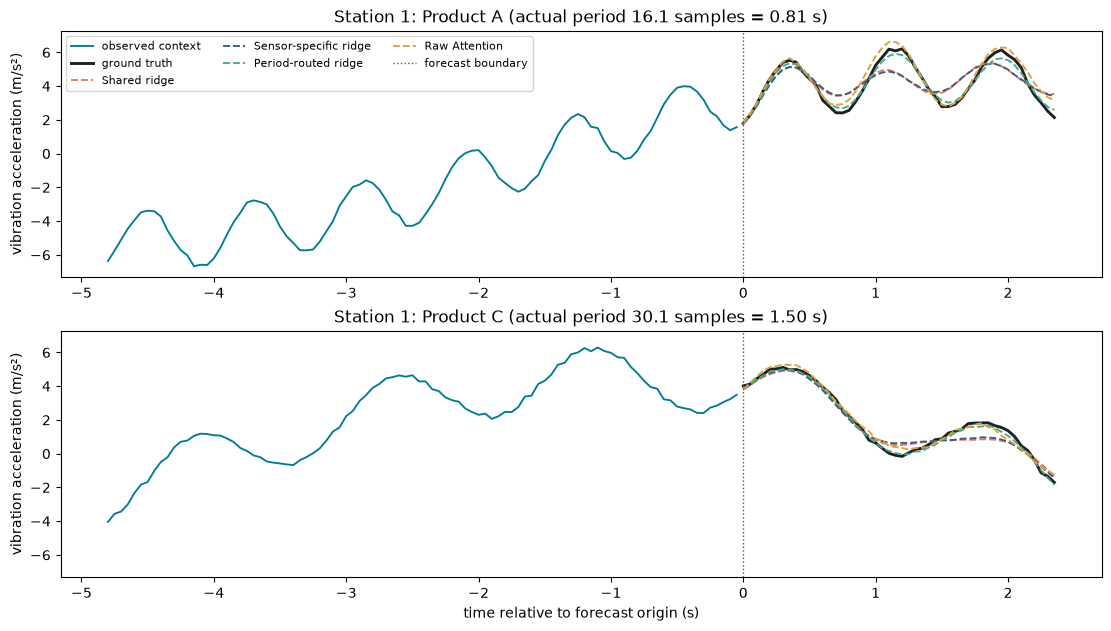

In [5]:
report.publish("1.2", figures.regime_forecasts(
    study, ["Shared ridge", "Sensor-specific ridge", "Period-routed ridge", "Raw Attention"]))


Output 1.3


,station,product,actual period (samples),mean |Attention weight difference|,max |Attention weight difference|
0,1,Product A,16.135,unavailable,unavailable
1,1,Product C,30.093,unavailable,unavailable
2,1,Product A vs Product C (difference),unavailable,0.013,0.439


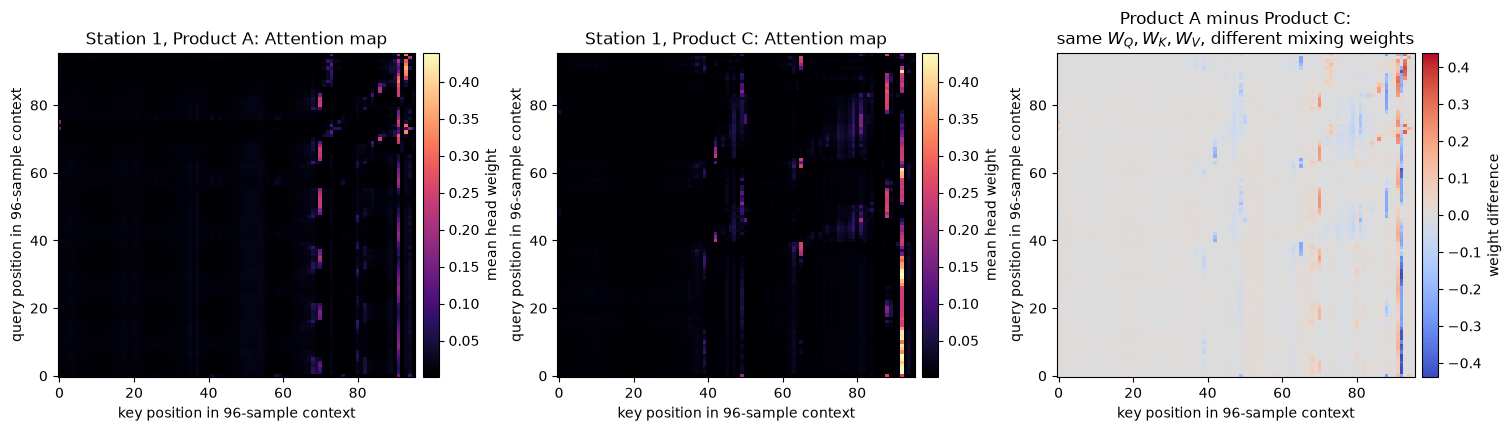

In [6]:
report.publish("1.3", figures.attention_behaviour(study))


## 2. Separate Slow Structure from Repetition

Switch 1. Across a 96-sample window the slow part of a reading is a smooth ramp, and it costs the
forecaster twice: the encoder spends representation on it, and it can hide the repeating
vibration. Splitting the context sends each stream to the part of the model suited to it, while
leaving the Attention mixer itself alone.

Implement the centered moving-average split below. Input and both outputs have shape
`(batch, time, channels)`; return `(remainder, trend)` **in that order**, so that
`remainder + trend == x` exactly.

The trap is the endpoints. For the first and last `kernel // 2` positions the averaging window
runs off the sequence: **replicate the nearest value there, rather than padding with zeros.**
Padding with zeros drags those positions toward zero, and it is the first thing the check
reports. The worked example below makes both endpoints visible before you run the check.

The supplied decomposed-Attention plumbing sends the remainder through Attention, the trend to a
linear head, and adds the two forecasts.

**Output 2.2 is an oracle diagnostic.** The synthetic generator's true period is available only
to score whether a width exposes the known repetition. It is not an input to the neural
forecaster, not a routing variable, and not information available in an ordinary deployment.

Produces **Outputs 2.1–2.3** → used in **Response 2**.

| Cell below | Output | Read it for |
| --- | --- | --- |
| trend/residual for several candidate widths | 2.1 | Response 2 |
| oracle primary-period recovery used to choose the width | 2.2 | Response 2 |
| decomposition ablation table and forecast shapes | 2.3 | Response 2 |


In [ ]:
class SeriesDecomposition(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        if kernel < 1 or kernel % 2 == 0:
            raise ValueError("kernel must be positive and odd")
        self.kernel = kernel

    def forward(self, x):                       # x [B,L,C] -> (remainder, trend), each [B,L,C]
        # trend[t] is the mean of x over the window [t - kernel//2, t + kernel//2].
        # Where that window runs off either end, repeat the nearest value in the sequence
        # rather than padding with zeros. Return x - trend as the remainder, so the two
        # streams reconstruct x exactly.
        radius = self.kernel // 2

        x_t = x.transpose(1, 2) # [B,L,C] -> [B,C,L]

        x_padded = F.pad(x_t, (radius, radius), mode='replicate') # [B, C, L+2*radius]

        # then we use unfold which creates a sliding window view of the tensor. The size of the window is self.kernel, and we step by 1 to get overlapping windows.
        windows = x_padded.unfold(dimension=2, size=self.kernel, step=1) # [B, C, L, kernel]

        trend_t = windows.mean(dim=-1) # [B, C, L]

        trend = trend_t.transpose(1, 2) # [B, C, L] -> [B, L, C]

        remainder = x - trend # [B, L, C]

        return remainder, trend


In [8]:
# Read this before running the check: kernel 3 on one short sequence, so the endpoint rule
# is visible. Interior: trend[1] = (1+2+3)/3 = 2. First position: the window needs x[-1], which
# is replicated from x[0], giving (1+1+2)/3 = 1.333 -- zero padding would give 1.0 instead.
example = torch.tensor([1., 2., 3., 10., 5.]).reshape(1, 5, 1)
remainder, trend = SeriesDecomposition(3)(example)
display(pd.DataFrame({
    "x": example.flatten(),
    "your trend": trend.flatten(),
    "expected trend": [4 / 3, 2., 5., 6., 20 / 3],
    "your remainder": remainder.flatten(),
}).round(4))


,x,your trend,expected trend,your remainder
0,1.0,1.3333,1.3333,-0.3333
1,2.0,2.0000,2.0000,0.0000
2,3.0,5.0000,5.0000,-2.0000
3,10.0,6.0000,6.0000,4.0000
4,5.0,6.6667,6.6667,-1.6667


Decomposition checks passed.
Decomposed-Attention assembly and gradient checks passed.
Output 2.1


,width,selected,residual std (m/s²),trend range (m/s²)
0,17,False,0.578,8.768
1,25,False,1.012,8.037
2,33,False,1.372,8.076
3,41,True,1.572,8.280


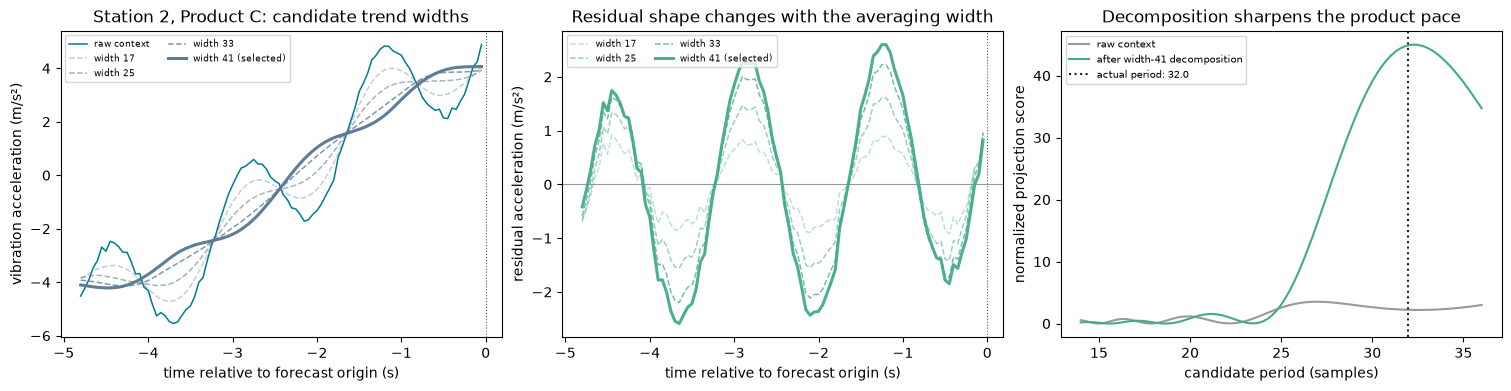

Output 2.2


,representation,oracle recovery within one sample,median absolute period error (samples),selected
0,raw,0.687,0.525,False
1,width 17,0.980,0.157,False
2,width 25,0.989,0.122,False
3,width 33,0.993,0.142,False
4,width 41,0.998,0.216,True


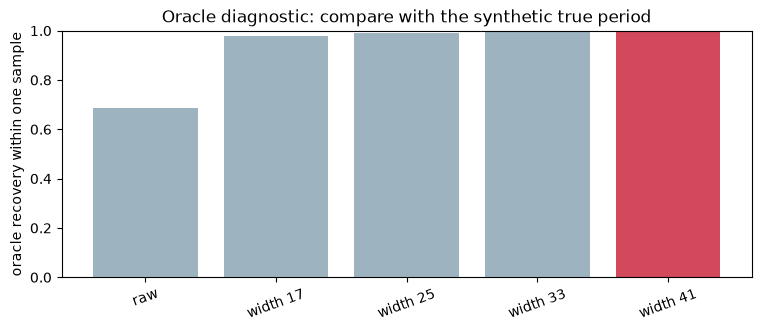

In [9]:
assert design.check_decomposition(SeriesDecomposition)
design.register_components(decomposition_type=SeriesDecomposition)

# Supplied Part 2 model: Attention mixes the remainder; a linear head forecasts the trend.
class DecompositionAttentionBlock(nn.Module):
    def __init__(self, d, heads, kernel, decomposition_type, dropout):
        super().__init__()
        self.mix = DenseAttention(d, heads)
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        self.strip1, self.strip2 = decomposition_type(kernel), decomposition_type(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class DecomposedAttentionForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 kernel=25, dropout=0.1, decomposition_type=None):
        super().__init__()
        self.split = decomposition_type(kernel)
        self.trend_head = nn.Linear(context, horizon)
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([DecompositionAttentionBlock(
            d, heads, kernel, decomposition_type, dropout) for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        return seasonal_forecast + self.trend_head(trend.squeeze(-1))

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks]

assert design.check_decomposed_attention_assembly(DecomposedAttentionForecaster, SeriesDecomposition)
design.register_components(decomposed_attention_forecaster_type=DecomposedAttentionForecaster)
report.publish("2.1", figures.filter_decomposition(study))
report.publish("2.2", figures.recurrence_recovery(study))


Attention + decomposition: 6000 steps, 59.6s, 373024 parameters, best established-validation MSE 0.091 (m/s²)² -- same physical units as the report tables below
Attention + decomposition: saved attention-decomposition-full-data0-model0-3b30d5f30515.pt
Output 2.3


,model,population,product,MSE,RMSE (m/s²),MAE (m/s²)
0,Raw Attention,established,Product A,0.148,0.384,0.288
1,Raw Attention,established,Product B,0.191,0.437,0.328
2,Raw Attention,established,Product C,0.158,0.397,0.299
3,Raw Attention,held-out,Product A,0.311,0.558,0.422
4,Raw Attention,held-out,Product B,0.313,0.560,0.420
5,Raw Attention,held-out,Product C,0.352,0.593,0.437
6,Attention + decomposition,established,Product A,0.078,0.279,0.214
7,Attention + decomposition,established,Product B,0.115,0.339,0.252
8,Attention + decomposition,established,Product C,0.080,0.283,0.212
9,Attention + decomposition,held-out,Product A,0.162,0.402,0.307


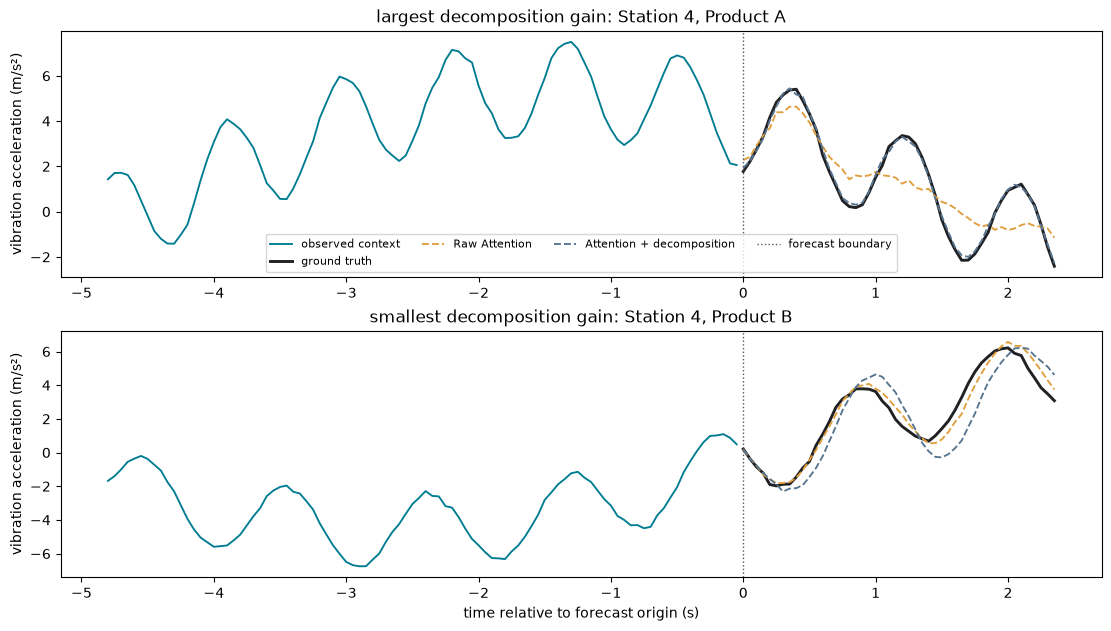

In [10]:
study.train("Attention + decomposition")
report.publish("2.3", figures.decomposition_ablation(study))


## 3. Mix by Temporal Delay

Switch 2 replaces the mixer rather than changing what the mixer is shown. Delay mixing scores
every delay, keeps the best few from the fixed band, sharpens them with a learned temperature,
and combines shifted copies of the context. Scoring every delay (`delay_scores`) is supplied;
you write the aggregation (`aggregate_delays`) that turns scored delays into a mixed sequence.

The mental model is: **score delays → select useful delays → shift values → combine them.**

Produces **Outputs 3.1–3.2** → used in **Response 3**.


### Delay scores (supplied)

`delay_scores(queries, keys)` takes tensors of shape `(batch, heads, features, time)` and returns
one score per delay, of shape `(batch, time)`. It is supplied below: it computes every delay's
score with two real forward FFTs and one inverse real FFT, in `O(L log L)` rather than the
`O(L^2)` a loop over delays would cost. You do not need to derive or reconstruct this procedure.

| Cell below | Output | Read it for |
| --- | --- | --- |
| the supplied scores on `[1, 3, 1, 3]`, against a direct calculation | 3.1 | Response 3 |


In [11]:
def delay_scores(queries, keys):
    # queries, keys: [B,heads,features,L] -> scores [B,L], one per delay tau = 0 .. L-1.
    # R(tau) = sum_t q[t] * k[(t - tau) mod L], centered in time, averaged over heads and
    # features. Supplied: an FFT computes every delay's score together in O(L log L).
    queries = queries - queries.mean(-1, keepdim=True)
    keys = keys - keys.mean(-1, keepdim=True)
    spectrum = torch.fft.rfft(queries, dim=-1) * torch.fft.rfft(keys, dim=-1).conj()
    return torch.fft.irfft(spectrum, n=queries.shape[-1], dim=-1).mean((1, 2))


In [12]:
# delay_scores is supplied above. This toy example confirms it against a direct circular
# correlation for q = k = [1, 3, 1, 3], which centers to [-1, 1, -1, 1].
example = torch.tensor([1., 3., 1., 3.]).reshape(1, 1, 1, 4)
scores = pd.DataFrame({"delay": range(4),
                       "delay_scores (FFT)": delay_scores(example, example).flatten().tolist(),
                       "direct circular correlation": [4., -4., 4., -4.]})
display(scores.round(6))

assert design.check_delay_scores(delay_scores)
design.register_components(delay_scores=delay_scores)
report.publish("3.1", scores)


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


FFT delay-score checks passed.
Output 3.1


,delay,delay_scores (FFT),direct circular correlation
0,0,4.0,4.0
1,1,-4.0,-4.0
2,2,4.0,4.0
3,3,-4.0,-4.0


### Delay aggregation

`aggregate_delays(values, delays, weights)` takes `values` of shape
`(batch, heads, features, time)` plus `delays` and `weights` of shape `(batch, K)`, and returns the
weighted circular shifts, of shape `(batch, heads, features, time)` — the same shape as `values`.

Position `t` reads the value from `t - delay`, wrapping modulo `L`. Each example carries its own
delays and weights, shared across that example's heads and features.

The worked example below is the handout's aggregation case, and its first entry decides the direction:
`z0 = 35` means your shift runs the right way, `z0 = 25` means it runs backwards. That is the
single most common bug in this cell.

The next cell checks this aggregation immediately with the worked example and a gradient test.


In [13]:
def aggregate_delays(values, delays, weights):
    # values: [B,heads,features,L]; delays, weights: [B,K] -> [B,heads,features,L]
    # z[t] = sum_j weights[j] * values[(t - delays[j]) mod L], per example, shared across
    # that example's heads and features. Keep it differentiable in both values and weights.
    
    B, H, F, L = values.shape
    K = delays.shape[1]
    
    # tensor of positions t from 0 to L-1
    t = torch.arange(L, device=values.device).view(1, 1, 1, 1, L) # [1, 1, 1, 1, L]
    
    # reshaping delays for broadcasting against t
    d = delays.view(B, 1, 1, K, 1) # [B, 1, 1, K, 1]
    
    # calculating the circular indices: (t - delay) mod L
    indices = (t - d) % L # [B, 1, 1, K, L]
    
    # expanding indices and values to the full shape [B, H, F, K, L] 
    indices = indices.expand(B, H, F, K, L)
    values_exp = values.unsqueeze(3).expand(B, H, F, K, L)
    
    # gathering the shifted values
    shifted_values = torch.gather(values_exp, dim=-1, index=indices) # [B, H, F, K, L]
    
    # reshaping weights for broadcasting
    w = weights.view(B, 1, 1, K, 1) # [B, 1, 1, K, 1]
    
    # multiplying by weights and sum over the K delays
    z = (shifted_values * w).sum(dim=3) # [B, H, F, L]
    
    return z


In [14]:
# Let v = [10, 20, 30, 40], delays [1, 3], and weights [3/4, 1/4].
# z0 = 3/4 * v[3] + 1/4 * v[1] = 30 + 5 = 35. If you get 25, the shift runs the wrong way.
values = torch.tensor([10., 20., 30., 40.]).reshape(1, 1, 1, 4)
mixed = aggregate_delays(values, torch.tensor([[1, 3]]), torch.tensor([[.75, .25]]))
aggregated = pd.DataFrame({"position": range(4),
                           "your aggregated value": mixed.flatten(),
                           "expected": [35., 15., 25., 25.]})
display(aggregated.round(6))

assert design.check_aggregation(aggregate_delays)
design.register_components(aggregate=aggregate_delays)


,position,your aggregated value,expected
0,0,35.0,35.0
1,1,15.0,15.0
2,2,25.0,25.0
3,3,25.0,25.0


Delay-aggregation checks passed.


### Delay mixer (supplied)

`DelayMixer` applies the full sequence: it projects the context into q/k/v features, calls the
supplied scorer, selects useful delays, and calls your aggregation function to combine the
shifted values.


In [15]:
class DelayMixer(nn.Module):
    def __init__(self, d, heads, delay_score_fn, aggregate_fn, min_delay=8, max_delay=48):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads, self.min_delay, self.max_delay = heads, min_delay, max_delay
        self.delay_score_fn, self.aggregate_fn = delay_score_fn, aggregate_fn
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.raw_temperature = nn.Parameter(torch.tensor(0.5413248546))

    @property
    def temperature(self):
        return F.softplus(self.raw_temperature) + 1e-6

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).permute(0, 2, 3, 1)
                   for layer in (self.query, self.key, self.value))  # [B,h,d_h,L]
        scores = self.delay_score_fn(q, k)      # [B,L]
        lo, hi = self.min_delay, min(self.max_delay, length - 1)
        band = scores[:, lo:hi + 1]
        top_k = min(math.ceil(2 * math.log(length)), band.shape[-1])
        selected, indices = band.topk(top_k, dim=-1)
        delays = indices + lo                  # [B,K]
        weights = (selected / self.temperature).softmax(-1)  # [B,K]
        mixed = self.aggregate_fn(v, delays, weights)         # [B,h,d_h,L]
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, length, width))


### Output 3.2 — Signal-level recurrence diagnostic

This diagnostic correlates raw and residual **signal values** directly. It does **not** show the
trained mixer's learned q/k delay scores. It makes the repeating-delay assumption visible; the
model scores learned projected features.


Output 3.2


,station,product,expected delay (samples),nearest integer delay,residual signal correlation
0,2,Product A,16.135,16,0.896
1,2,Product A,32.269,32,0.897


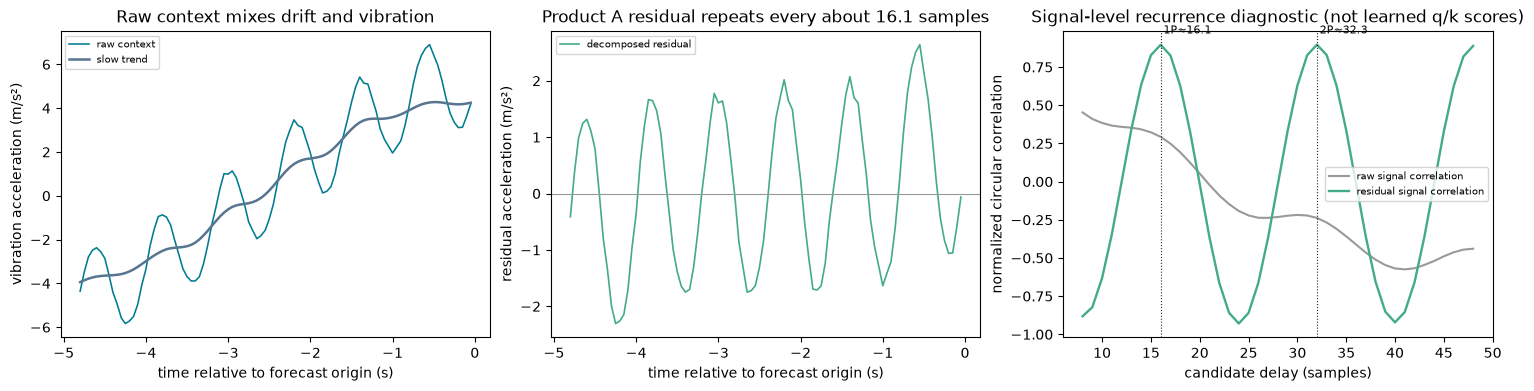

In [16]:
recurrence = figures.delay_recurrence(study)
report.publish("3.2", recurrence)


## 4. Compare Designs and Deploy

Nothing new to implement. Before running Output 4.1, write the prediction requested in
**Response 4** in at most two sentences. You now know both switches, so this part introduces the
supplied unified network. The four models are that one network with the two switches thrown
differently. The combined decomposed-delay configuration is called **Autoformer-inspired**.
They share width, depth, data order, optimizer schedule, and
checkpoint policy; they do **not** share parameter count or runtime, which Output 4.1 reports in
separate columns.

Produces **Outputs 4.1–4.3** → used in **Response 4**.

| Cell below | Output | Read it for |
| --- | --- | --- |
| fit the two remaining models; comparison table and contrasting forecast cases | 4.1 | Response 4 — write its prediction first |
| error along the 48-step horizon | 4.2 | Response 4 |
| selected models and their validation/test results | 4.3 | Response 4 |


Model assembly and gradient checks passed (4 setting(s): raw/attention, raw/delay, decomposed/attention, decomposed/delay).
Raw delay mixer: 6000 steps, 36.4s, 368370 parameters, best established-validation MSE 0.053 (m/s²)² -- same physical units as the report tables below
Raw delay mixer: saved raw-delay-mixer-full-data0-model0-ad0d4fd609a5.pt
Autoformer-inspired: 6000 steps, 69.5s, 373026 parameters, best established-validation MSE 0.038 (m/s²)² -- same physical units as the report tables below
Autoformer-inspired: saved autoformer-inspired-full-data0-model0-8e6025e992be.pt
Output 4.1


,model,established stations RMSE (m/s²),established stations MSE (m/s²)²,"established stations, Product A RMSE","established stations, Product B RMSE","established stations, Product C RMSE",held-out station 4 RMSE (m/s²),held-out station 4 MSE (m/s²)²,"held-out station 4, Product A RMSE","held-out station 4, Product B RMSE","held-out station 4, Product C RMSE",parameters,fit seconds
0,Raw Attention,0.407,0.165,0.384,0.437,0.397,0.571,0.325,0.558,0.560,0.593,368368,27.400
1,Raw delay mixer,0.229,0.053,0.211,0.210,0.264,0.338,0.114,0.404,0.282,0.315,368370,36.426
2,Attention + decomposition,0.302,0.091,0.279,0.339,0.283,0.455,0.207,0.402,0.493,0.466,373024,59.632
3,Autoformer-inspired,0.195,0.038,0.218,0.190,0.175,0.245,0.060,0.275,0.229,0.229,373026,69.452


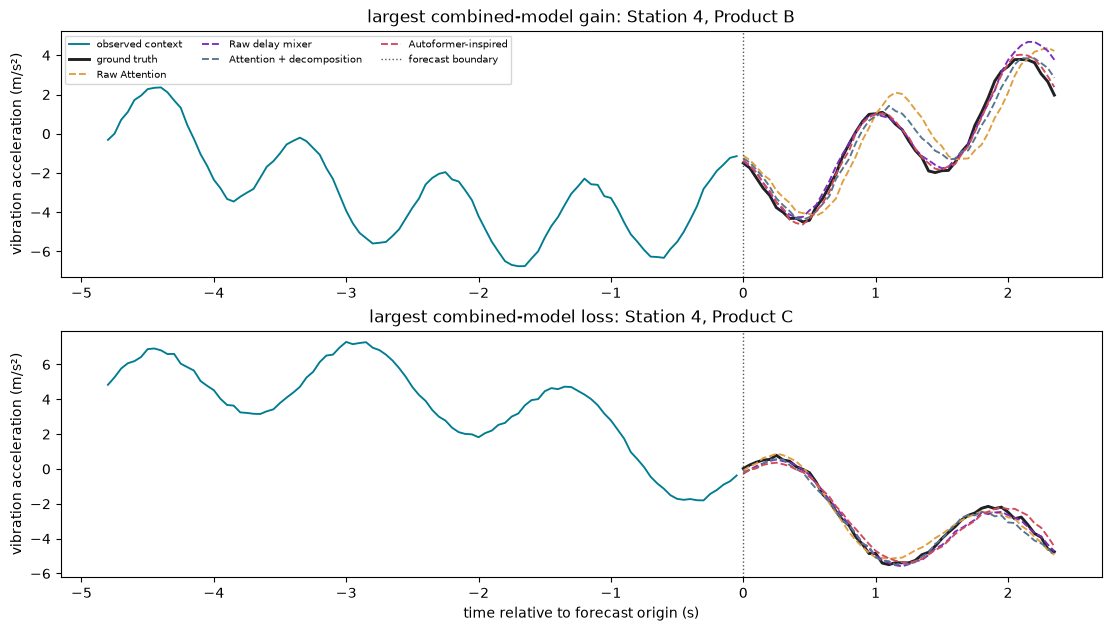

,case,station,product,model,window RMSE (m/s²)
0,largest combined-model gain,4,Product B,Raw Attention,1.208
1,largest combined-model gain,4,Product B,Raw delay mixer,0.510
2,largest combined-model gain,4,Product B,Attention + decomposition,0.607
3,largest combined-model gain,4,Product B,Autoformer-inspired,0.215
4,largest combined-model loss,4,Product C,Raw Attention,0.263
5,largest combined-model loss,4,Product C,Raw delay mixer,0.226
6,largest combined-model loss,4,Product C,Attention + decomposition,0.268
7,largest combined-model loss,4,Product C,Autoformer-inspired,0.354


In [17]:
# Supplied unified 2×2 design.
class IdentitySplit(nn.Module):
    def forward(self, x):
        return x, torch.zeros_like(x)

class EncoderBlock(nn.Module):
    def __init__(self, d, heads, mixing, kernel, decomposition_type,
                 delay_score_fn, aggregate_fn, dropout):
        super().__init__()
        self.mix = (DelayMixer(d, heads, delay_score_fn, aggregate_fn)
                    if mixing == "delay" else DenseAttention(d, heads))
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        split = decomposition_type if decomposition_type is not None else lambda _: IdentitySplit()
        self.strip1, self.strip2 = split(kernel), split(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]

class AutoformerInspiredForecaster(nn.Module):
    def __init__(self, context=96, horizon=48, channels=1, d=64, heads=4, layers=2,
                 mixing="attention", representation="raw", kernel=25, dropout=0.1,
                 decomposition_type=None, delay_score_fn=None, aggregate_fn=None):
        super().__init__()
        if representation not in {"raw", "decomposed"}:
            raise ValueError("representation must be 'raw' or 'decomposed'")
        self.split = (decomposition_type(kernel) if representation == "decomposed"
                      else IdentitySplit())
        self.trend_head = nn.Linear(context, horizon) if representation == "decomposed" else None
        self.embed = nn.Conv1d(channels, d, 3, padding=1, padding_mode="circular", bias=False)
        self.position = nn.Parameter(torch.randn(1, context, d) * 0.02)
        self.blocks = nn.ModuleList([EncoderBlock(
            d, heads, mixing, kernel, decomposition_type, delay_score_fn, aggregate_fn, dropout)
            for _ in range(layers)])
        self.norm = nn.LayerNorm(d)
        self.forecast_head = nn.Linear(context * d, horizon)

    def forward(self, context):                 # [B,L,1] -> [B,H]
        seasonal, trend = self.split(context)
        encoded = self.embed(seasonal.transpose(1, 2)).transpose(1, 2) + self.position
        for block in self.blocks:
            encoded = block(encoded)
        seasonal_forecast = self.forecast_head(self.norm(encoded).flatten(1))
        trend_forecast = 0 if self.trend_head is None else self.trend_head(trend.squeeze(-1))
        return seasonal_forecast + trend_forecast

    @property
    def attention_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DenseAttention)]

    @property
    def delay_layers(self):
        return [block.mix for block in self.blocks if isinstance(block.mix, DelayMixer)]

assert design.check_assembly(AutoformerInspiredForecaster)
design.register_components(forecaster_type=AutoformerInspiredForecaster)
study.train("Raw delay mixer")
study.train("Autoformer-inspired")
cases = figures.contrasting_forecasts(study)
report.publish("4.1", report.comparison(study, [
    "Raw Attention", "Raw delay mixer", "Attention + decomposition", "Autoformer-inspired"]))
display(cases.round(3))


Output 4.2


,model,population,horizon,MSE,RMSE (m/s²)
0,Period-routed ridge,established,1,0.013,0.112
1,Period-routed ridge,established,2,0.011,0.107
2,Period-routed ridge,established,3,0.014,0.118
3,Period-routed ridge,established,4,0.014,0.118
4,Period-routed ridge,established,5,0.015,0.121
...,...,...,...,...,...
475,Autoformer-inspired,held-out,44,0.108,0.329
476,Autoformer-inspired,held-out,45,0.117,0.342
477,Autoformer-inspired,held-out,46,0.105,0.324
478,Autoformer-inspired,held-out,47,0.096,0.310


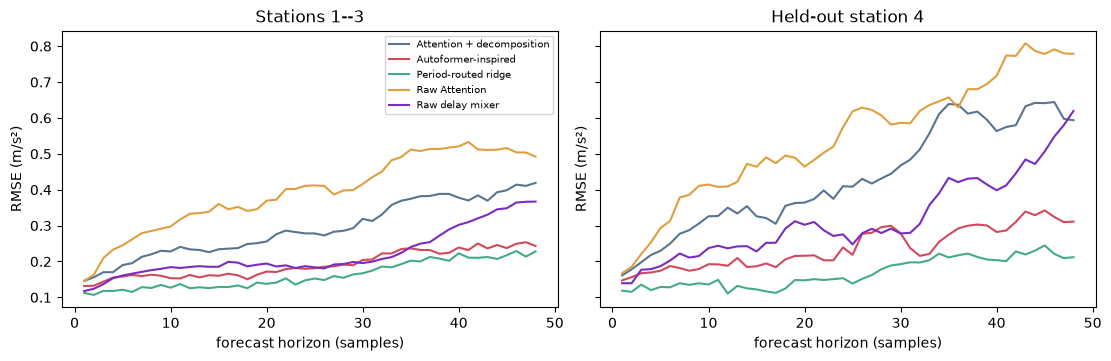

In [18]:
report.publish("4.2", figures.horizon_figure(study, [
    "Period-routed ridge", "Raw Attention", "Raw delay mixer",
    "Attention + decomposition", "Autoformer-inspired"]))


### Choose the deployment models (Response 4)

Choose one fitted model for the established stations and one for held-out station 4 using validation
MSE, physical-unit RMSE, parameter count, and fitting time,
then enter both model names below. Output 4.3 reports their validation and test results.

The compact validation-only decision summary below collects the error and cost quantities needed
for this choice. It is not another Output; Outputs 1.1 and 4.1–4.2 remain the detailed evidence.

| Cell below | Output | Read it for |
| --- | --- | --- |
| enter both choices | — | Response 4 |
| validation/test results for both choices | 4.3 | Response 4 |


In [19]:
# Validation-only decision summary.
display(report.deployment_summary(study).round(3))


,model,established validation RMSE (m/s²),established validation MSE (m/s²)²,held-out validation RMSE (m/s²),held-out validation MSE (m/s²)²,parameters,fit seconds
0,Shared ridge,0.767,0.588,0.876,0.767,4608,0.003
1,Sensor-specific ridge,0.768,0.590,NaN,NaN,13824,0.018
2,Period-routed ridge,0.166,0.028,0.173,0.030,59904,0.002
3,Raw Attention,0.407,0.165,0.571,0.325,368368,27.400
4,Attention + decomposition,0.302,0.091,0.455,0.207,373024,59.632
5,Raw delay mixer,0.229,0.053,0.338,0.114,368370,36.426
6,Autoformer-inspired,0.195,0.038,0.245,0.060,373026,69.452


In [23]:
choices = {
    "established": 'Period-routed ridge',  # exact fitted model name chosen from validation evidence
    "held-out": 'Period-routed ridge',
}
display(study.select_for_test(choices))


,population,model
0,established,Period-routed ridge
1,held-out,Period-routed ridge


In [24]:
report.publish("4.3", study.selected_test_table())


Output 4.3


,population,model,validation MSE,validation RMSE (m/s²),test MSE,test RMSE (m/s²)
0,established,Period-routed ridge,0.028,0.166,0.026,0.161
1,held-out,Period-routed ridge,0.030,0.173,0.033,0.183
